Loaded: C:\temp\credit_card_transaction_flow_cleaneddataa.csv shape: (50000, 9)
       Customer ID       Name    Surname Gender   Birthdate  \
0           752858       Sean  Rodriguez      F  20-10-2002   
1            26381   Michelle     Phelps    NaN  24-10-1985   
2           305449      Jacob   Williams      M  25-10-1981   
3           988259     Nathan     Snyder      M  26-10-1977   
4           764762    Crystal      Knapp      F  02-11-1951   
...            ...        ...        ...    ...         ...   
49995       891845  Christine      Leach      F  21-10-1997   
49996       800560       Anna      Allen      F  21-10-1999   
49997       133285     Nicole   Franklin      M  26-10-1979   
49998       616122      Maria     Keller      M  25-10-1981   
49999       832184      Billy     Walker      F  31-10-1958   

       Transaction Amount        Date                 Merchant Name  \
0                   35.47  03-04-2023                 Smith-Russell   
1                 255

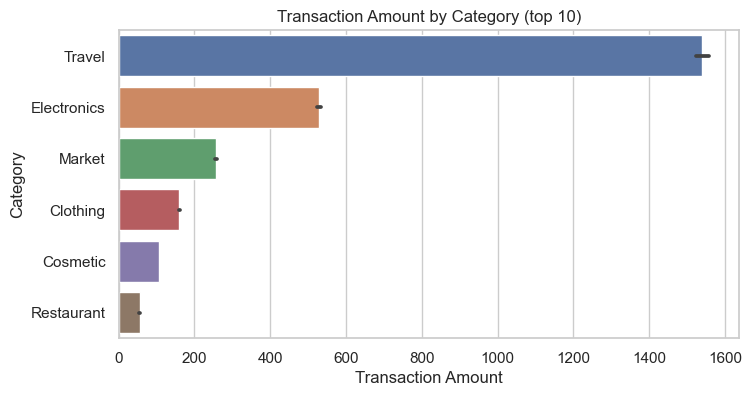

None        Customer ID       Name    Surname Gender   Birthdate  \
0           752858       Sean  Rodriguez      F  20-10-2002   
1            26381   Michelle     Phelps    NaN  24-10-1985   
2           305449      Jacob   Williams      M  25-10-1981   
3           988259     Nathan     Snyder      M  26-10-1977   
4           764762    Crystal      Knapp      F  02-11-1951   
...            ...        ...        ...    ...         ...   
49995       891845  Christine      Leach      F  21-10-1997   
49996       800560       Anna      Allen      F  21-10-1999   
49997       133285     Nicole   Franklin      M  26-10-1979   
49998       616122      Maria     Keller      M  25-10-1981   
49999       832184      Billy     Walker      F  31-10-1958   

       Transaction Amount        Date                 Merchant Name  \
0                   35.47  03-04-2023                 Smith-Russell   
1                 2552.72  17-07-2023        Peck, Spence and Young   
2                  115.97

In [20]:
'''
EDA Skeleteon- Personal Modular Workflow
Author: Shailesh Pawar
Version 1.3
Last Updated: Nov 2025
Purpose: Quick Modular EDA on any dataset.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
cols=["Transaction Amount"]
path=r"C:\temp\credit_card_transaction_flow_cleaneddataa.csv"
df = pd.read_csv(path)
def load_data(path, parse_dates=None):
    try:
        path=r"C:\temp\credit_card_transaction_flow_cleaneddataa.csv"
        df = pd.read_csv(path, parse_dates=parse_dates)
        print("Loaded:", path, "shape:", df.shape)
        return df
    except Exception as e:
        print("Load error:", e)
        raise

def health_check(df,cols):
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Info:")
    print(df.info())
    print("Missing:\n", df.isnull().sum())
    print("Duplicates:", df.duplicated().sum())
    print("Unique counts:\n", df.nunique())

def coerce_numeric(df, cols):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def basic_stats(df, cols):
    s = df[cols].describe()
    print(s)
    return s

def bar_by_category(df, x="Category", y="Transaction Amount", top_n=10):
    order = df.groupby(x)[y].mean().sort_values(ascending=False).head(top_n).index
    plt.figure(figsize=(8,4))
    sns.barplot(data=df, y=x, x=y, order=order)
    plt.title(f"{y} by {x} (top {top_n})")
    plt.show()

# Example usage:
# df = load_data("credit_card_transaction_flow_cleaneddata.csv", parse_dates=['Date'])
# health_check(df)
# df = coerce_numeric(df, ['Transaction Amount'])
# basic_stats(df, 'Transaction Amount')
# bar_by_category(df, 'Category', 'Transaction Amount', top_n=8)
print(load_data("C:\temp\credit_card_transaction_flow_cleaneddataa.csv"))
print()
print(health_check(df,cols),coerce_numeric(df, cols),basic_stats(df, cols),bar_by_category(df, x="Category", y="Transaction Amount", top_n=10))